# Problem 5

### Problem
$$
\begin{align*}
u(x, y) &= \sin(\alpha \pi (x + y)), \\
\end{align*}
$$

From the Paper:
This solution and the respective function $f(x, y) = -2 \alpha^{2} \pi^{2} \sin(\alpha \pi (x + y))$ present rapidly growing derivatives for large values of $\alpha$. In Tables VIII and IX we present relative errors in the norm $\|\cdot\|_{\infty}$ when solving the Dirichlet problem for $\alpha = 5$ and $\alpha = 20$, respectively. Here we have adopted the trapezoidal rule for evaluating the radial integrals.

For the case $\alpha = 5$ the dominant parameter is the number of circles $M$ regardless of the number of Fourier coefficients in use. In fact, quadratic convergence depending on $M$ can be observed in Table VIII. For the larger value $\alpha = 20$ functions $u$ and $f$ oscillate rapidly, and the derivatives increase in absolute value.

The Fourier spaces of dimension $N = 64$ and $N = 128$ do not allow a good representation of $u$ and $f$ as one can observe on the first two rows of relative residual in Table IX. However, for $N = 256$ or larger, the Fourier space provides a good representation of these functions, and the quadratic convergence on $M$ resumes (rows 3, 4, 5, and 6 in Table IX). This problem shows the importance of using Fourier representation when dealing with rapidly oscillating functions.

# Imports

In [1]:
import os
import sys
import platform
import psutil
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = True  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters
# Solver Parameters (Uniform Grid)
num_processors = None  # Number of CPU threads (None = all available cores)
maxiter_nufft = 50     # Maximum CG iterations
tol_nufft = 1e-8       # CG residual tolerance
reg_param = 1e-12      # Regularization parameter
eps_finufft = 1e-12    # FINUFFT kernel precision

from uniform_testing_helpers_2 import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

backend_name = 'GPU (NVIDIA CuPy / cuFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY')
print('=' * 75)
print(f'  Active Backend  : {backend_name}')
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

if USE_GPU:
    try:
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
        compute_cap = f"{props['major']}.{props['minor']}"
        free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
        
        print('-' * 75)
        print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
        print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
        print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    except Exception as e:
        print(f'  GPU Status      : Warning - GPU query failed: {e}')

print(f'  Time Trials     : {TIME_TRIALS} (Runs = {NUM_RUNS})')
print('=' * 75)


  BENCHMARK ENVIRONMENT SUMMARY
  Active Backend  : GPU (NVIDIA CuPy / cuFFT)
  Environment     : Google Colab (Linux 6.6.122+)
  Host CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
  CPU Cores       : 6 Physical / 12 Logical Threads
  System RAM      : 53.0 GB Total (51.1 GB Available)
---------------------------------------------------------------------------
  GPU Device      : NVIDIA L4 (Compute Capability: 8.9)
  GPU VRAM        : 22.0 GB Total (21.7 GB Free)
  CUDA Driver/RT  : 12090
  Time Trials     : True (Runs = 5)


# Problem Setup

In [2]:

R = 1.0
rad_unif = 1
BC_MAP = {"dirichlet": 1, "neumann": 2}
QUAD_MAP = {"trapezoidal": 1, "simpson": 2}

methods = [
    {"name": "fft", "label": "Uniform FFT", "azu_unif": 2, "mesh_kind": "uniform", "use_nudft": False}
]

N_values = [64, 128, 256, 512, 1024, 2048]
M_values = [64, 128, 256, 512, 1024, 2048]
alphas = [5, 20]

# Solver settings
maxiter_nufft = 50
tol_nufft = 1e-8
reg_param = 1e-12
eps_finufft = 1e-12


# Run Code, table 

In [3]:

df_tables = {}
runtime_summary = []

for alpha in tqdm(alphas, desc="Problem 5 (alpha loop)", unit="alpha"):
    u, f, g_dirichlet, g_neumann = setup_problem_5(alpha)

    t0 = time.perf_counter()
    df_tables[alpha] = run_table_1_tracked(
        methods, N_values, M_values, u, f, g_dirichlet, g_neumann,
        BC_MAP, QUAD_MAP, rad_unif, R,
        num_processors=num_processors, use_gpu=USE_GPU,
        time_trials=TIME_TRIALS, num_runs=NUM_RUNS,
        maxiter_nufft=maxiter_nufft, tol_nufft=tol_nufft,
        reg_param=reg_param, eps_finufft=eps_finufft,
        desc=f"alpha={alpha}"
    )
    total_time = time.perf_counter() - t0

    runtime_summary.append({
        "alpha": alpha,
        "n_cases": len(N_values) * len(M_values),
        "total_time_s": total_time,
        "avg_time_per_case_s": total_time / (len(N_values) * len(M_values)),
    })

df_runtime = pd.DataFrame(runtime_summary)


Problem 5 (alpha loop):   0%|          | 0/2 [00:00<?, ?alpha/s]

alpha=5:   0%|          | 0/36 [00:00<?, ?case/s]

alpha=20:   0%|          | 0/36 [00:00<?, ?case/s]

# View Results

In [4]:
def dash_if_nan(x):
    return "—" if pd.isna(x) else f"{x:.1e}"

for alpha in alphas:
    print(f"\n{'='*80}\nUniform FFT : PROBLEM 5 (alpha={alpha}) - L_inf_rel\n{'='*80}")
    display(df_tables[alpha].pivot(index="N", columns="M", values="L_inf_rel").reindex(index=N_values, columns=M_values).map(dash_if_nan))



Uniform FFT : PROBLEM 5 (alpha=5) - L_inf_rel


M,64,128,256,512,1024,2048
N,,,,,,
64,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.4e-05
128,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
256,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
512,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
1024,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05
2048,1.4e-02,3.4e-03,8.4e-04,2.1e-04,5.2e-05,1.3e-05



Uniform FFT : PROBLEM 5 (alpha=20) - L_inf_rel


M,64,128,256,512,1024,2048
N,,,,,,
64,2.6e+01,2.5e+01,2.5e+01,2.5e+01,2.5e+01,2.5e+01
128,2.2e+00,2.1e+00,2.1e+00,2.1e+00,2.1e+00,2.1e+00
256,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,2.5e-04
512,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,2.5e-04
1024,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,2.5e-04
2048,2.8e-01,6.5e-02,1.6e-02,4.0e-03,1.0e-03,2.5e-04


## Figures from Original Paper


<div style="max-width:500px;">

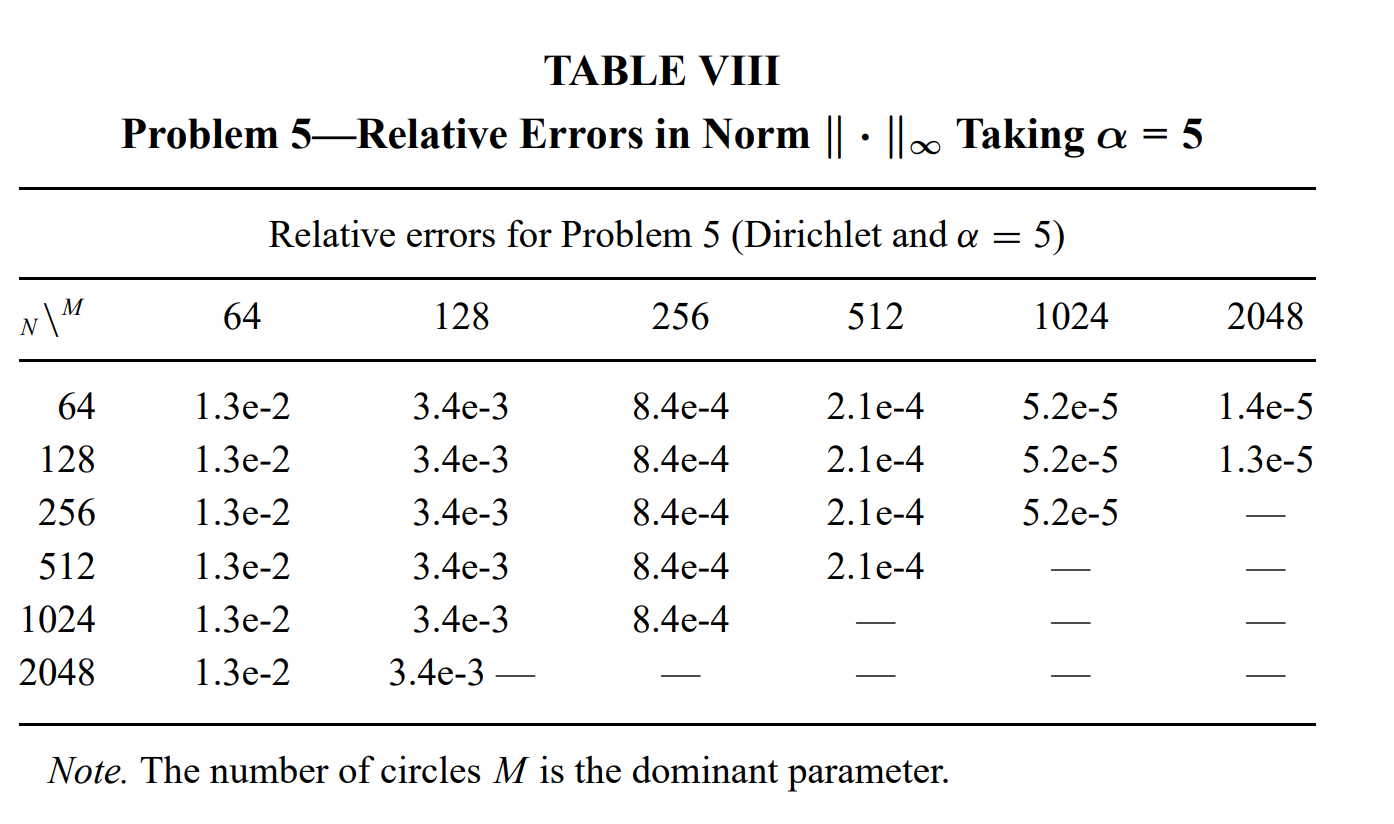

</div>


<div style="max-width:500px;">

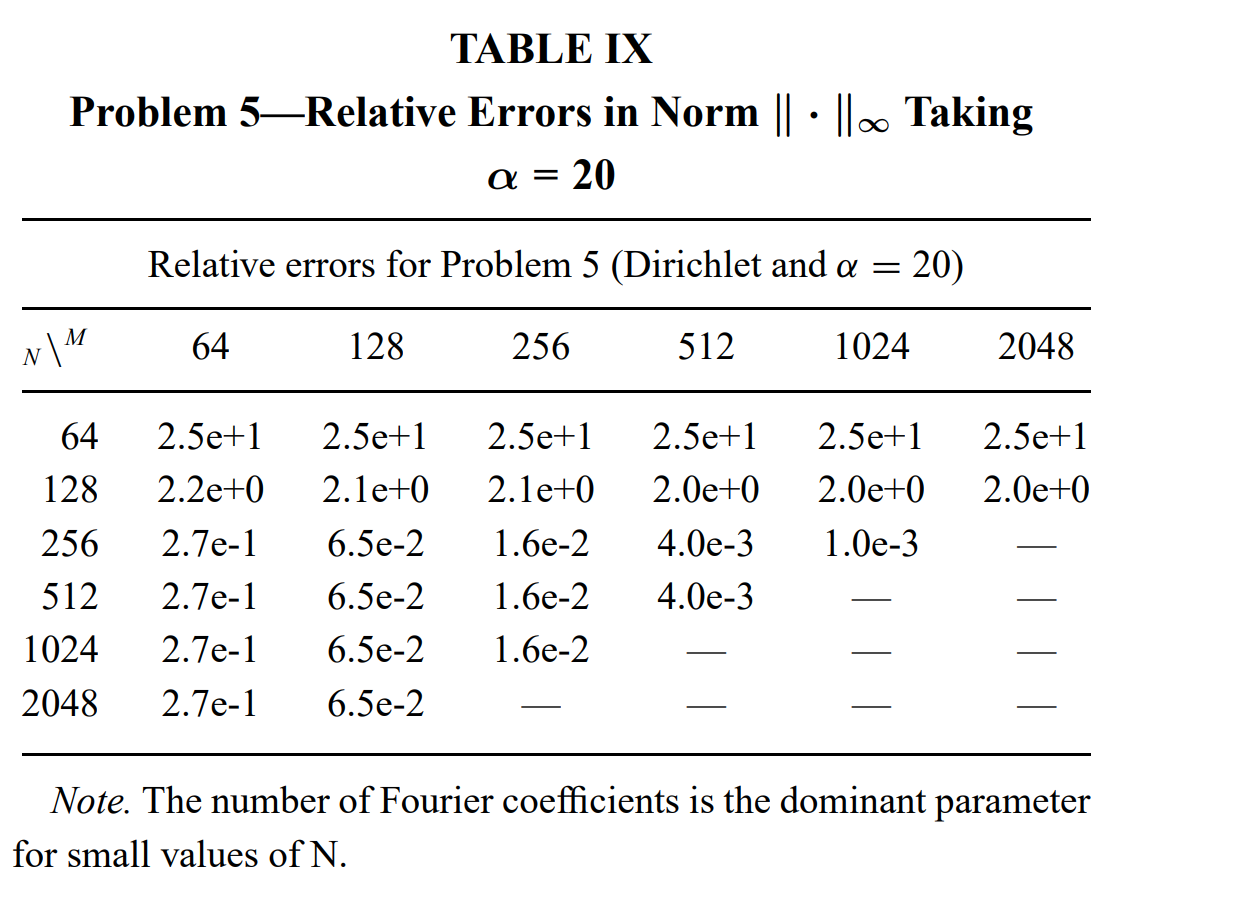

</div>

# Plots and Runtimes

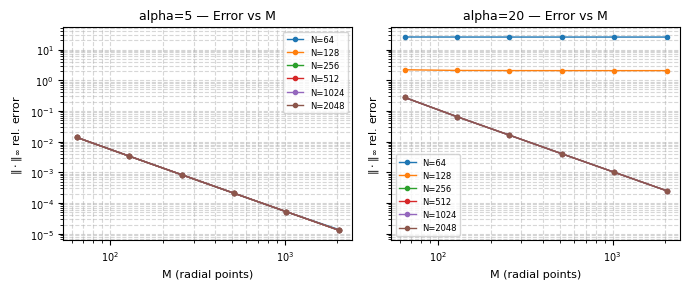

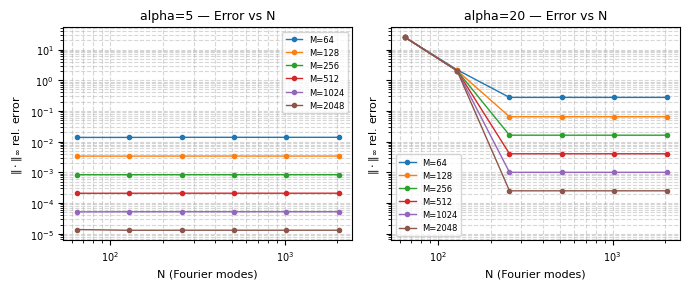


Uniform FFT : PROBLEM 5 (alpha=5) - Solver Time (s)


M,64,128,256,512,1024,2048
N,,,,,,
64,0.030,0.043,0.070,0.121,0.230,0.441
128,0.031,0.043,0.071,0.124,0.232,0.452
256,0.031,0.045,0.074,0.133,0.248,0.481
512,0.034,0.051,0.085,0.152,0.281,0.544
1024,0.034,0.052,0.087,0.153,0.291,0.575
2048,0.035,0.054,0.089,0.163,0.310,0.618



Uniform FFT : PROBLEM 5 (alpha=20) - Solver Time (s)


M,64,128,256,512,1024,2048
N,,,,,,
64,0.029,0.044,0.070,0.121,0.229,0.437
128,0.030,0.043,0.071,0.126,0.234,0.451
256,0.031,0.046,0.075,0.136,0.253,0.474
512,0.033,0.050,0.085,0.148,0.281,0.544
1024,0.035,0.052,0.089,0.160,0.293,0.574
2048,0.034,0.053,0.088,0.161,0.309,0.619



RUNTIME SUMMARY


,alpha,n_cases,total_time_s,avg_time_per_case_s
0,5,36,52.075311,1.446536
1,20,36,38.732723,1.075909


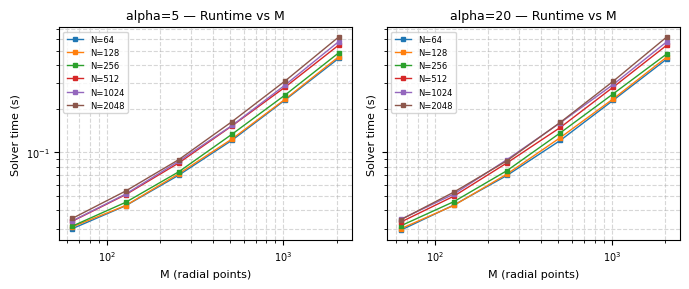

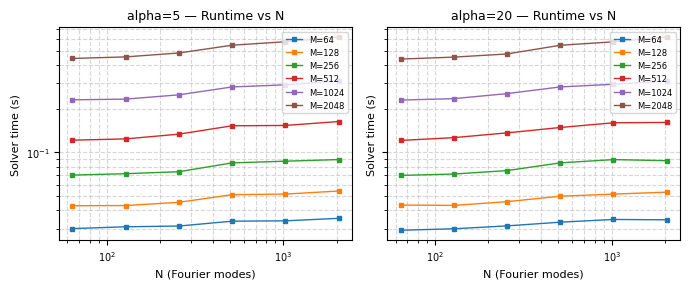

In [5]:


# --- Plots: error & runtime vs M (faceted by alpha) ---
fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for N in N_values:
        sub = df_a[df_a["N"] == N].sort_values("M")
        ax.loglog(sub["M"], sub["L_inf_rel"], marker="o", markersize=3, linewidth=1, label=f"N={N}")
    ax.set_xlabel("M (radial points)", fontsize=8)
    ax.set_ylabel(r"$\|\cdot\|_\infty$ rel. error", fontsize=8)
    ax.set_title(f"alpha={alpha} — Error vs M", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for M in M_values:
        sub = df_a[df_a["M"] == M].sort_values("N")
        ax.loglog(sub["N"], sub["L_inf_rel"], marker="o", markersize=3, linewidth=1, label=f"M={M}")
    ax.set_xlabel("N (Fourier modes)", fontsize=8)
    ax.set_ylabel(r"$\|\cdot\|_\infty$ rel. error", fontsize=8)
    ax.set_title(f"alpha={alpha} — Error vs N", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Per-case timing tables
for alpha in alphas:
    print(f"\n{'='*80}\nUniform FFT : PROBLEM 5 (alpha={alpha}) - Solver Time (s)\n{'='*80}")
    display(df_tables[alpha].pivot(index="N", columns="M", values="time").reindex(index=N_values, columns=M_values).map(lambda x: "—" if pd.isna(x) else f"{x:.3f}"))

# Overall runtime summary table
print(f"\n{'='*80}\nRUNTIME SUMMARY\n{'='*80}")
display(df_runtime)



fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for N in N_values:
        sub = df_a[df_a["N"] == N].sort_values("M")
        ax.loglog(sub["M"], sub["time"], marker="s", markersize=3, linewidth=1, label=f"N={N}")
    ax.set_xlabel("M (radial points)", fontsize=8)
    ax.set_ylabel("Solver time (s)", fontsize=8)
    ax.set_title(f"alpha={alpha} — Runtime vs M", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, len(alphas), figsize=(3.5 * len(alphas), 3), sharey=True)
if len(alphas) == 1:
    axes = [axes]

for ax, alpha in zip(axes, alphas):
    df_a = df_tables[alpha]
    for M in M_values:
        sub = df_a[df_a["M"] == M].sort_values("N")
        ax.loglog(sub["N"], sub["time"], marker="s", markersize=3, linewidth=1, label=f"M={M}")
    ax.set_xlabel("N (Fourier modes)", fontsize=8)
    ax.set_ylabel("Solver time (s)", fontsize=8)
    ax.set_title(f"alpha={alpha} — Runtime vs N", fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Publication Visualizations (Problem 5)

### Solution and Pointwise Error Visualizations on Disk
1. **1 x 2 Plot**: Exact analytic solutions $u(x, y) = \sin(\alpha \pi (x + y))$ for the two configured alphas (e.g. $\alpha = 5$ and $\alpha = 20$).
2. **2 x 2 Plot**: Direct comparison between exact solutions (Row 1) and numerical approximations with $M = 2048$ and $N = 64$ (Row 2).
3. **2 x 2 Plot**: Numerical approximations with $M = 2048$ and $N = 64$ (Row 1) and their corresponding pointwise error surfaces $|u - u_h|$ (Row 2).


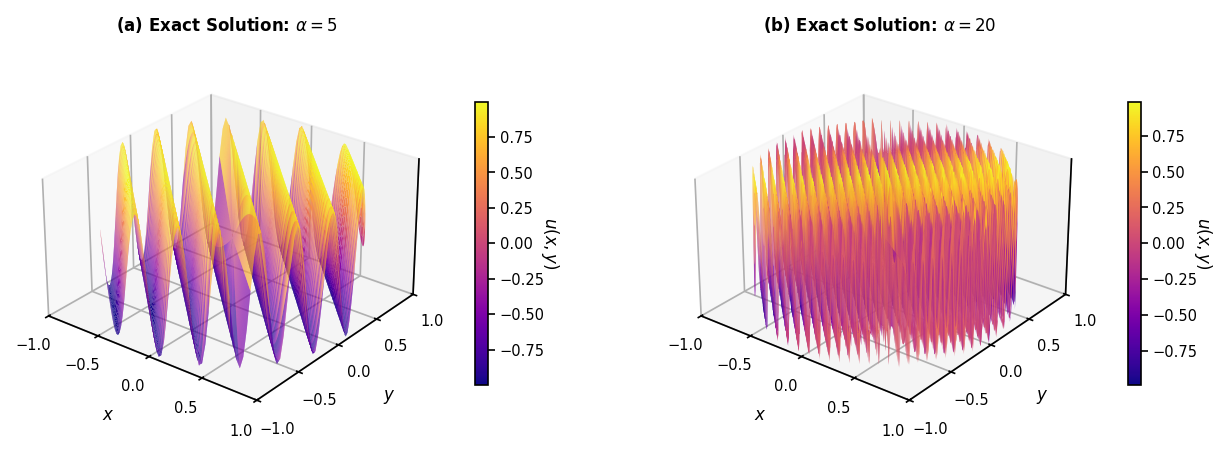

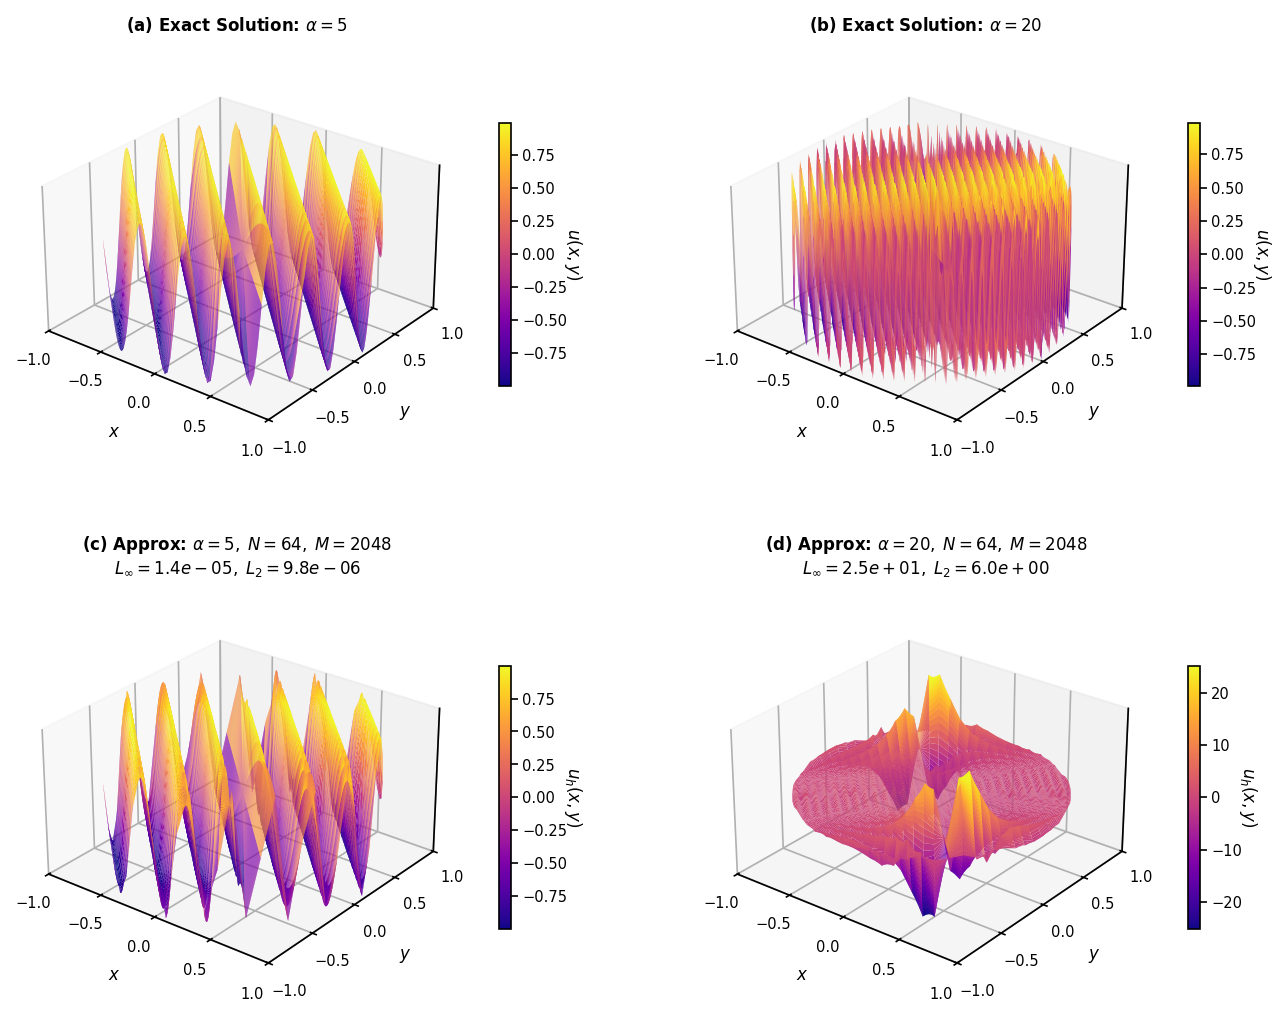

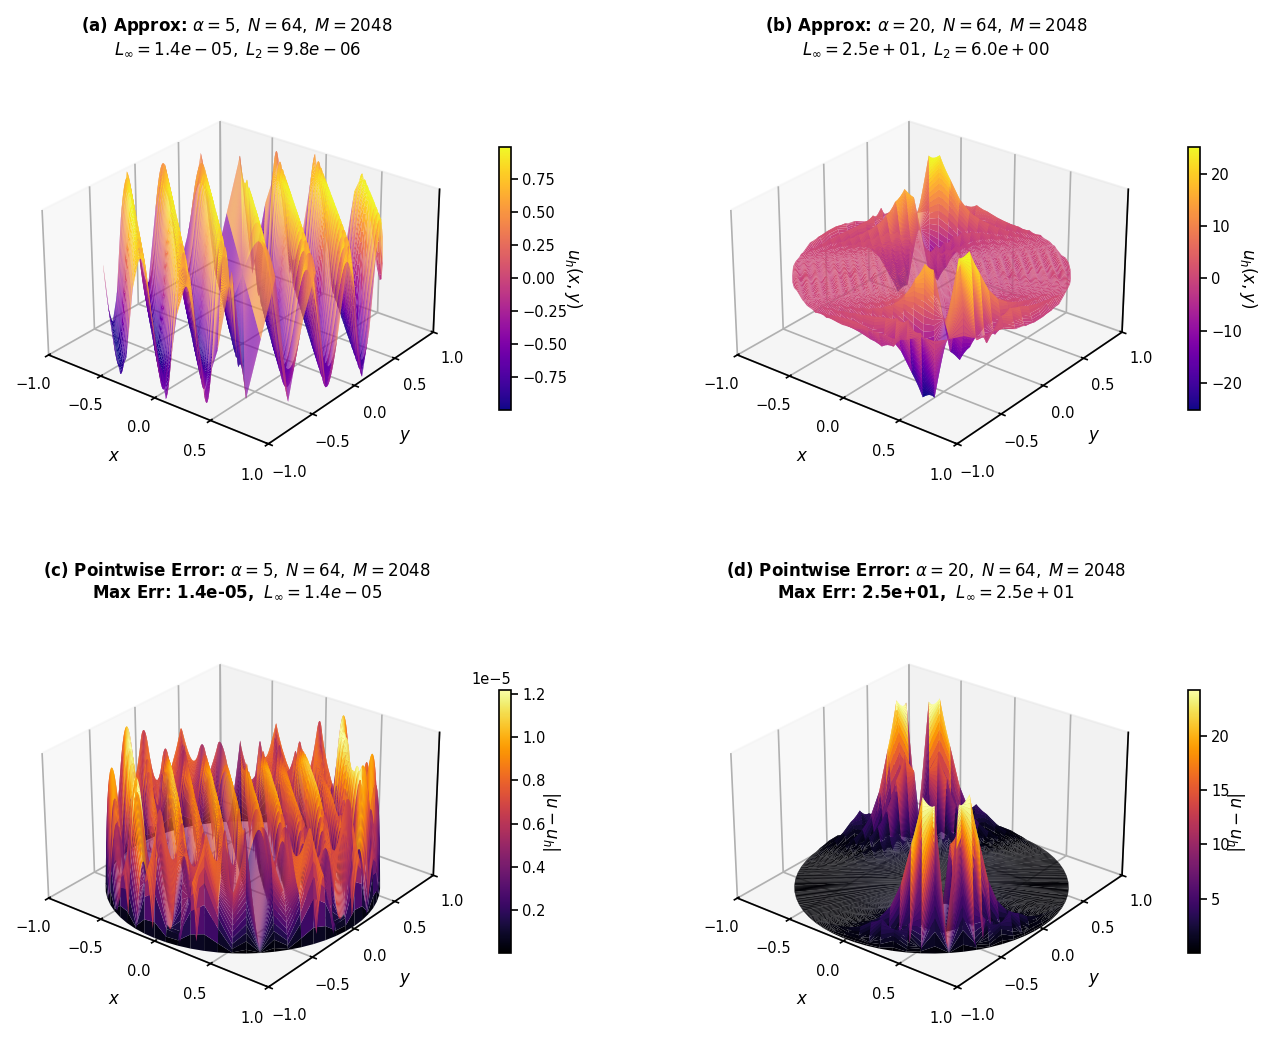

In [6]:

#1x2 True solutions for alpha = 5 and 20 (or configured alphas)
fig1 = plot_problem5_true_solutions(alphas=alphas, R=R)

#2x2 True solutions (Row 1) vs Approximations (M=2048, N=64, Row 2)
fig2 = plot_problem5_true_vs_approx(alphas=alphas, N=64, M=2048, R=R, use_gpu=USE_GPU)


#2x2 Approximations (Row 1) vs Pointwise Errors (Row 2)
fig3 = plot_problem5_approx_and_error(alphas=alphas, N=64, M=2048, R=R, use_gpu=USE_GPU)
